## Airy differential equation

Airy differential equation looks simple:

$$
    y''(x) - x \, y(x) = 0
$$

But it cannot be solved analytically. Any solution is a linear combination of special functions Ai(x) and Bi(x).

We can implement a numerical Taylor 4th-order method to solve it. Rewrite the differential equation as a system:

\begin{cases}
    y'(x) = v(x) \\
    v'(x) = x \, y(x)
\end{cases}

By Taylor series, we can discretize it as follows:

$$
    \begin{cases}
    y_{n + 1} = y_n + h \, v_n + \dfrac{h ^ 2}{2} x_n \, y_n + \dfrac{h ^ 3}{6} \bigl(y_n + x_n \, v_n \bigr) + \dfrac{h ^ 4}{24} \bigl(2 \, v_n + x_n ^ 2 \, y_n \bigr) \\
    v_{n + 1} = v_n + h \, x_n \, y_n + \dfrac{h ^ 2}{2} \bigl(y_n + x_n \, v_n \bigr) + \dfrac{h ^ 3}{6} \bigl(2 \, v_n + x_n ^ 2 \, y_n \bigr) + \dfrac{h ^ 4}{24} x_n \bigl(4 \, y_n + x_n \, v_n \bigr)
    \end{cases}
$$

Derivation available in *PDF* folder using Maxima CAS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy # Airy functions from SciPy

In [2]:
def taylor4_airy(x0, y0, v0, x_end, h): # Solves Airy differential equation using a 4th order method

    n = int((x_end - x0) / h) # Number of subdivisions

    # Initial setup
    x, y, v = np.empty(shape = (3, n + 1), dtype = np.float64, order = 'C')
    x[0], y[0], v[0] = x0, y0, v0

    for i in range(n):
        xn, yn, vn = (x[i], y[i], v[i])

        # Update yn using the formula
        term1 = h * vn
        term2 = (h ** 2 / 2.0) * xn * yn
        term3 = (h ** 3 / 6.0) * (yn + xn * vn)
        term4 = (h ** 4 / 24.0) * (2.0 * vn + xn ** 2 * yn)
        
        yn1 = sum([yn, term1, term2, term3, term4]) # Parallel addition reduces algorithmic error
        
        # Update vn using the formula
        term1 = h * xn * yn
        term2 = (h ** 2 / 2.0) * (yn + xn * vn)
        term3 = (h ** 3 / 6.0) * (2.0 * vn + xn ** 2 * yn)
        term4 = (h ** 4 / 24.0) * xn * (4.0 * yn + xn * vn)
        
        vn1 = sum([vn, term1, term2, term3, term4])

        # Updates arrays
        x[i + 1] = xn + h
        y[i + 1] = yn1
        v[i + 1] = vn1

    return (x, y, v) # Return x, solution y and derivative of y

In [3]:
# Setup differential equation
x0, x_end = (- 10.0, 2.0)
h = 0.1 # Step size

Ai0, Aip0, Bi0, Bip0 = airy(x0) # Initial conditions (Airy, to obtain Ai(x) and Bi(x))

In [4]:
x, y_ai, v_ai = taylor4_airy(x0, Ai0, Aip0, x_end, h) # Numerical solution Ai(x)
_, y_bi, v_bi = taylor4_airy(x0, Bi0, Bip0, x_end, h) # Numerical solution Bi(x)

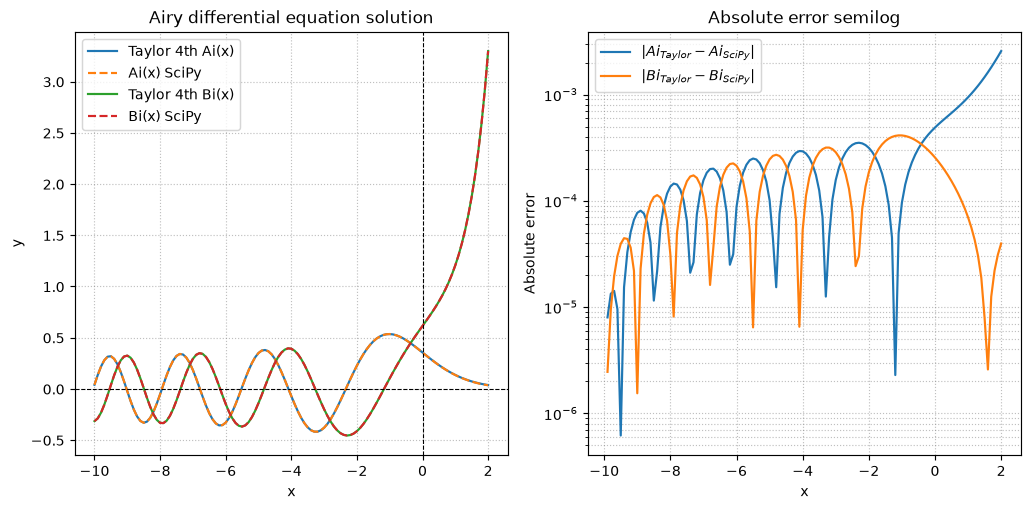

In [5]:
# Exact solutions
Ai_ref, Aip_ref, Bi_ref, Bip_ref = airy(x)

# Plotting solutions
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

# Solutions comparison
ax1.plot(x, y_ai, label = 'Taylor 4th Ai(x)')
ax1.plot(x, Ai_ref, linestyle = '--', label = 'Ai(x) SciPy')
ax1.plot(x, y_bi, label = 'Taylor 4th Bi(x)')
ax1.plot(x, Bi_ref, linestyle = '--', label = 'Bi(x) SciPy')
ax1.axhline(color = 'black', linestyle = '--', linewidth = 0.75)
ax1.axvline(color = 'black', linestyle = '--', linewidth = 0.75)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title("Airy differential equation solution")
ax1.grid(linestyle = ':', color = 'gray', alpha = 0.5)
ax1.legend(loc = 'best')

# Absolute errors plot
err_y_ai_exact = np.abs(y_ai - Ai_ref)
err_y_bi_exact = np.abs(y_bi - Bi_ref)

ax2.semilogy(x[1:], err_y_ai_exact[1:], label = r'$|Ai_{Taylor} - Ai_{SciPy}|$')
ax2.semilogy(x[1:], err_y_bi_exact[1:], label = r'$|Bi_{Taylor} - Bi_{SciPy}|$')
ax2.set_xlabel('x')
ax2.set_ylabel('Absolute error')
ax2.set_title("Absolute error semilog")
ax2.grid(linestyle = ':', color = 'gray', alpha = 0.5, which = 'both')
ax2.legend(loc = 'best')

plt.tight_layout()
plt.show()

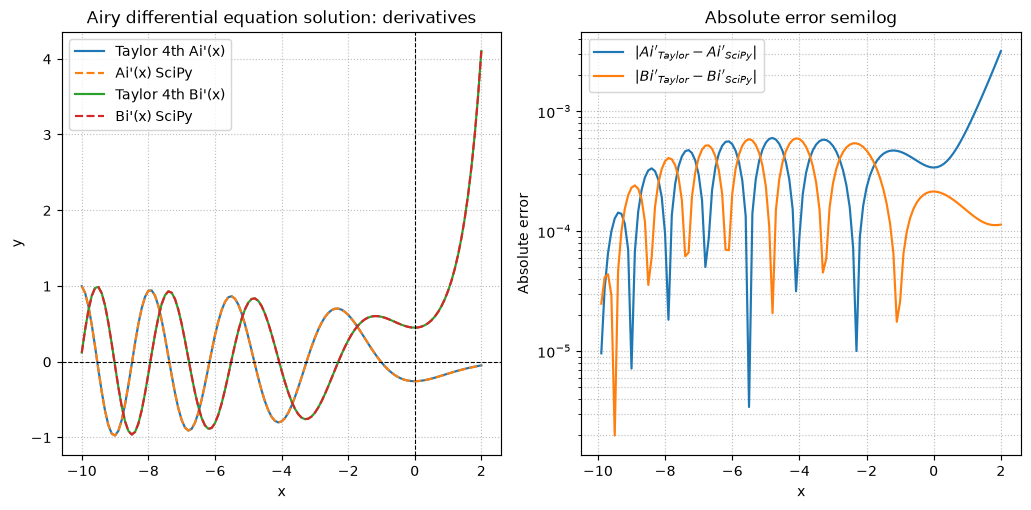

In [6]:
# Plotting derivatives
_, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

# Derivatives comparison
ax1.plot(x, v_ai, label = "Taylor 4th Ai'(x)")
ax1.plot(x, Aip_ref, linestyle = '--', label = "Ai'(x) SciPy")
ax1.plot(x, v_bi, label = "Taylor 4th Bi'(x)")
ax1.plot(x, Bip_ref, linestyle = '--', label = "Bi'(x) SciPy")
ax1.axhline(color = 'black', linestyle = '--', linewidth = 0.75)
ax1.axvline(color = 'black', linestyle = '--', linewidth = 0.75)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title("Airy differential equation solution: derivatives")
ax1.grid(linestyle = ':', color = 'gray', alpha = 0.5)
ax1.legend(loc = 'best')

# Absolute errors plot
err_v_ai_exact = np.abs(v_ai - Aip_ref)
err_v_bi_exact = np.abs(v_bi - Bip_ref)

ax2.semilogy(x[1:], err_v_ai_exact[1:], label = r"$|Ai'_{Taylor} - Ai'_{SciPy}|$")
ax2.semilogy(x[1:], err_v_bi_exact[1:], label = r"$|Bi'_{Taylor} - Bi'_{SciPy}|$")
ax2.set_xlabel('x')
ax2.set_ylabel('Absolute error')
ax2.set_title("Absolute error semilog")
ax2.grid(linestyle = ':', color = 'gray', alpha = 0.5, which = 'both')
ax2.legend(loc = 'best')

plt.tight_layout()
plt.show()

Let's estimate the global error in each point using Richardson method, to test it. If we assume that the error is:

$$
    E_h(x) \propto h ^ 4
$$

We can estimate the global error of $y(x)$ as:

$$
    E_h(x) = \frac{16}{15} \left| y_{h / 2}(x) - y_{h}(x) \right|
$$

In [7]:
# Richardson error estimations for h = 0.1
_, y_ai2, v_ai2 = taylor4_airy(x0, Ai0, Aip0, x_end, h / 2.0) # h / 2
_, y_bi2, v_bi2 = taylor4_airy(x0, Bi0, Bip0, x_end, h / 2.0) # h / 2

err_y_ai_rich = (16.0 * np.abs(y_ai2[::2] - y_ai) / 15.0)[1:] # Removing first element (error is exactly zero at the starting point)
err_y_bi_rich = (16.0 * np.abs(y_bi2[::2] - y_bi) / 15.0)[1:]
err_v_ai_rich = (16.0 * np.abs(v_ai2[::2] - v_ai) / 15.0)[1:]
err_v_bi_rich = (16.0 * np.abs(v_bi2[::2] - v_bi) / 15.0)[1:]

In [8]:
np.max(err_y_ai_rich), np.max(err_v_ai_rich), np.max(err_y_bi_rich), np.max(err_v_bi_rich), # Maximum errors by Richardson

(np.float64(0.0025662922851588704),
 np.float64(0.003188488186563765),
 np.float64(0.0004135654260813822),
 np.float64(0.0005961370265624266))

In [9]:
np.max(err_y_ai_exact), np.max(err_v_ai_exact), np.max(err_y_bi_exact), np.max(err_v_bi_exact), # Maximum real errors committed

(np.float64(0.0025641799180741096),
 np.float64(0.0031852867029111692),
 np.float64(0.0004129314606617848),
 np.float64(0.0005959665323800462))

In [10]:
# Differences with real errors committed
delta_err_y_ai = np.abs(err_y_ai_exact[1:] - err_y_ai_rich)
delta_err_v_ai = np.abs(err_v_ai_exact[1:] - err_v_ai_rich)
delta_err_y_bi = np.abs(err_y_bi_exact[1:] - err_y_bi_rich)
delta_err_v_bi = np.abs(err_v_bi_exact[1:] - err_v_bi_rich)

In [11]:
np.max(delta_err_y_ai), np.max(delta_err_v_ai), np.max(delta_err_y_bi), np.max(delta_err_v_bi) # Maximum delta (very small)

(np.float64(3.1552224138975404e-06),
 np.float64(4.686850160536454e-06),
 np.float64(1.9499340228742075e-05),
 np.float64(2.4160950853158172e-05))

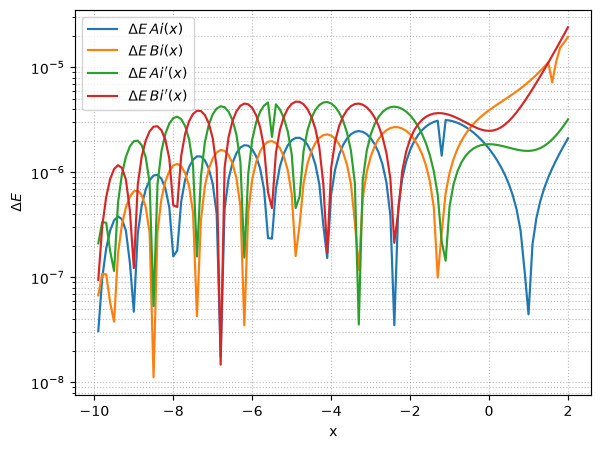

In [12]:
# Plotting delta
plt.semilogy(x[1:], delta_err_y_ai, label = r'$\Delta E \, Ai(x)$')
plt.semilogy(x[1:], delta_err_y_bi, label = r'$\Delta E \, Bi(x)$')
plt.semilogy(x[1:], delta_err_v_ai, label = r"$\Delta E \, Ai'(x)$")
plt.semilogy(x[1:], delta_err_v_bi, label = r"$\Delta E \, Bi'(x)$")
plt.xlabel('x')
plt.ylabel(r'$\Delta E$')
plt.legend(loc = 'best')
plt.grid(linestyle = ':', color = 'gray', alpha = 0.5, which = 'both')
plt.show()

As we can see, with $h = 0.1$, Richardson estimation works very well. The differences between the real errors committed and the estimated errors by Richardson are negligible (because we take only the first significant digit)

Another method to estimate a global error is to solve again the problem using a 5th-order method, that should be more accurate

In [13]:
def taylor5_airy(x0, y0, v0, x_end, h): # Solves Airy differential equation using a 5th-order method

    n = int((x_end - x0) / h) # Number of subdivisions

    # Initial setup
    x, y, v = np.empty(shape = (3, n + 1), dtype = np.float64, order = 'C')
    x[0], y[0], v[0] = x0, y0, v0

    for i in range(n):
        xn, yn, vn = (x[i], y[i], v[i])

        # Update yn using the formula
        term1 = h * vn
        term2 = (h ** 2 / 2.0) * xn * yn
        term3 = (h ** 3 / 6.0) * (yn + xn * vn)
        term4 = (h ** 4 / 24.0) * (2.0 * vn + xn ** 2 * yn)
        term5 = (h ** 5 / 120.0) * xn * (4.0 * yn + xn * vn) # New term added
        
        yn1 = sum([yn, term1, term2, term3, term4, term5]) # Parallel addition reduces algorithmic error
        
        # Update vn using the formula
        term1 = h * xn * yn
        term2 = (h ** 2 / 2.0) * (yn + xn * vn)
        term3 = (h ** 3 / 6.0) * (2.0 * vn + xn ** 2 * yn)
        term4 = (h ** 4 / 24.0) * xn * (4.0 * yn + xn * vn)
        term5 = (h ** 5 / 120.0) * (xn ** 3 * yn + 4.0 * yn + 6.0 * xn * vn)
        
        vn1 = sum([vn, term1, term2, term3, term4, term5])

        # Updates arrays
        x[i + 1] = xn + h
        y[i + 1] = yn1
        v[i + 1] = vn1

    return (x, y, v) # Return x, solution y and derivative of y

In [14]:
_, y_ai_5th, v_ai_5th = taylor5_airy(x0, Ai0, Aip0, x_end, h) # Numerical solution Ai(x) using 5th-order Taylor method
_, y_bi_5th, v_bi_5th = taylor5_airy(x0, Bi0, Bip0, x_end, h) # Numerical solution Bi(x) using 5th-order Taylor method

# Errors estimations for 4th-order solutions
err_y_ai_order_comp = np.abs(y_ai_5th - y_ai)[1:]
err_v_ai_order_comp = np.abs(v_ai_5th - v_ai)[1:]
err_y_bi_order_comp = np.abs(y_bi_5th - y_bi)[1:]
err_v_bi_order_comp = np.abs(v_bi_5th - v_bi)[1:]

In [15]:
np.max(err_y_ai_order_comp), np.max(err_v_ai_order_comp), np.max(err_y_bi_order_comp), np.max(err_v_bi_order_comp), # Maximum estimated errors by order comparison

(np.float64(0.0025786138789033117),
 np.float64(0.0032067154641385043),
 np.float64(0.0004187902646043823),
 np.float64(0.0005971420236426522))

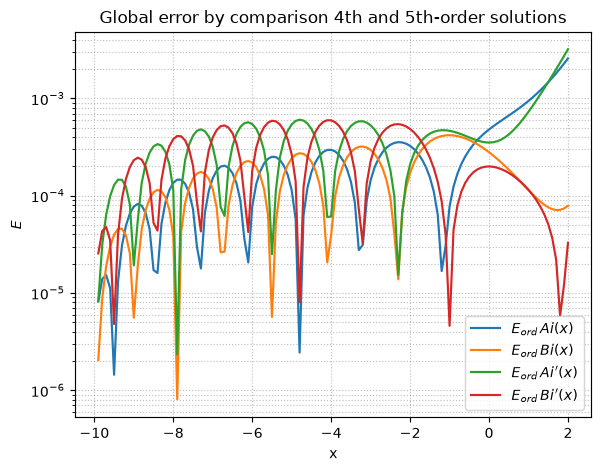

In [16]:
# Plotting errors
plt.title('Global error by comparison 4th and 5th-order solutions')
plt.semilogy(x[1:], err_y_ai_order_comp, label = r'$E_{ord} \, Ai(x)$')
plt.semilogy(x[1:], err_y_bi_order_comp, label = r'$E_{ord} \, Bi(x)$')
plt.semilogy(x[1:], err_v_ai_order_comp, label = r"$E_{ord} \, Ai'(x)$")
plt.semilogy(x[1:], err_v_bi_order_comp, label = r"$E_{ord} \, Bi'(x)$")
plt.xlabel('x')
plt.ylabel(r'$E$')
plt.legend(loc = 'best')
plt.grid(linestyle = ':', color = 'gray', alpha = 0.5, which = 'both')
plt.show()

In [17]:
# Richardson's method and order comparison method are compatible
np.max(np.abs(err_y_ai_order_comp - err_y_ai_rich)), np.max(np.abs(err_v_ai_order_comp - err_v_ai_rich)), np.max(np.abs(err_y_bi_order_comp - err_y_bi_rich)), np.max(np.abs(err_v_bi_order_comp - err_v_bi_rich))

(np.float64(1.5959288594250925e-05),
 np.float64(2.3815907204009318e-05),
 np.float64(6.998180331357536e-05),
 np.float64(8.919170992435591e-05))

In [ ]:
# For example, consider the solution Ai(x). Compare all errors together
for S, E, P in zip(err_y_ai_order_comp, err_y_ai_rich, err_y_ai_exact[1:]):
    print(f"{S:.1g} vs {E:.1g} vs {P:.1g}")

8e-06 vs 8e-06 vs 8e-06
1e-05 vs 1e-05 vs 1e-05
2e-05 vs 1e-05 vs 1e-05
1e-05 vs 1e-05 vs 1e-05
1e-06 vs 3e-07 vs 6e-07
1e-05 vs 2e-05 vs 2e-05
3e-05 vs 3e-05 vs 3e-05
5e-05 vs 5e-05 vs 5e-05
7e-05 vs 7e-05 vs 7e-05
8e-05 vs 8e-05 vs 8e-05
8e-05 vs 8e-05 vs 8e-05
8e-05 vs 8e-05 vs 8e-05
7e-05 vs 6e-05 vs 6e-05
5e-05 vs 4e-05 vs 4e-05
2e-05 vs 1e-05 vs 1e-05
2e-05 vs 2e-05 vs 2e-05
5e-05 vs 6e-05 vs 6e-05
8e-05 vs 9e-05 vs 9e-05
0.0001 vs 0.0001 vs 0.0001
0.0001 vs 0.0001 vs 0.0001
0.0001 vs 0.0001 vs 0.0001
0.0001 vs 0.0001 vs 0.0001
0.0001 vs 0.0001 vs 0.0001
0.0001 vs 0.0001 vs 0.0001
7e-05 vs 7e-05 vs 6e-05
3e-05 vs 2e-05 vs 2e-05
2e-05 vs 3e-05 vs 3e-05
7e-05 vs 7e-05 vs 7e-05
0.0001 vs 0.0001 vs 0.0001
0.0002 vs 0.0002 vs 0.0002
0.0002 vs 0.0002 vs 0.0002
0.0002 vs 0.0002 vs 0.0002
0.0002 vs 0.0002 vs 0.0002
0.0002 vs 0.0002 vs 0.0002
0.0002 vs 0.0002 vs 0.0002
0.0001 vs 0.0001 vs 0.0001
9e-05 vs 8e-05 vs 8e-05
4e-05 vs 3e-05 vs 3e-05
2e-05 vs 3e-05 vs 3e-05
8e-05 vs 9e-05 vs 9e-0